# Methodology & Results: ASEAN Green Bonds Impact Analysis

This notebook implements the complete causal inference pipeline:

1. **Propensity Score Matching (PSM)** - Create comparable treatment/control groups
2. **Difference-in-Differences (DiD)** - Estimate treatment effects
3. **Parallel Trends Testing** - Verify identification assumption
4. **Robustness Checks** - Placebo tests, sensitivity analysis
5. **Event Study** - Market reaction analysis
6. **Hypothesis Testing** - Greenwashing analysis

In [1]:
# Import modules
from asean_green_bonds import data, analysis, utils, config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Loading processed data...')
df = data.load_processed_data(which='engineered')
print(f'Data loaded: {df.shape[0]} observations, {df.shape[1]} variables')

Loading processed data...
Data loaded: 37630 observations, 63 variables


In [2]:
# Generate data quality report
print(utils.generate_data_quality_report(
    df,
    entity_col='ric',
    time_col='Year',
    treatment_col='green_bond_active'
))

DATA QUALITY REPORT

📊 PANEL STRUCTURE
   Entities: 4024
   Periods: 10
   Total observations: 37630
   Balanced: No (unbalanced panel)
   Missing combinations: 2610

📋 MISSING DATA
   Total missing: 488015 cells (20.6%)

⚠️  OUTLIERS DETECTED
   Columns with outliers: 43
   - ask_price: 4997 outliers
   - bid_price: 4662 outliers
   - capital_expenditures: 6465 outliers
   - cash: 5806 outliers
   - current_assets_total: 5356 outliers

🎯 TREATMENT VARIATION
   Treated entities: 27 / 4024
   Treatment prevalence: 0.5%
   Timing range: 7 years




PROPENSITY SCORE MATCHING

PSM Features: ['L1_Firm_Size', 'L1_Leverage', 'L1_Asset_Turnover', 'L1_Capital_Intensity', 'L1_Cash_Ratio']
Propensity scores estimated: 25436 observations

Optimal caliper (0.25 × SD): 0.0100
  Propensity score SD: 0.0018
  Fixed caliper comparison: 0.1

Trimming extreme propensity scores...
  Observations trimmed: 17281 (45.9%)

Common Support Analysis:
  Treated mean PS: 0.0010 (SD: 0.0006)
  Control mean PS: 0.0010 (SD: 0.0007)
  Overlap region: [0.0002, 0.0020]
  Violations: 0 treated, 3773 control

Performing nearest-neighbor matching (caliper=auto)...

Matching Results:
  Treated units: 12
  Matched treated: 12
  Unmatched treated: 0
  Matched controls: 48
  Total matched observations: 60
  Caliper used: 0.0100

Covariate Balance After Matching:
             Feature  Std_Difference  P_Value  Balanced
        L1_Firm_Size        0.185536 0.567608     False
         L1_Leverage       -0.078594 0.808467      True
   L1_Asset_Turnover        0.146617 0.65

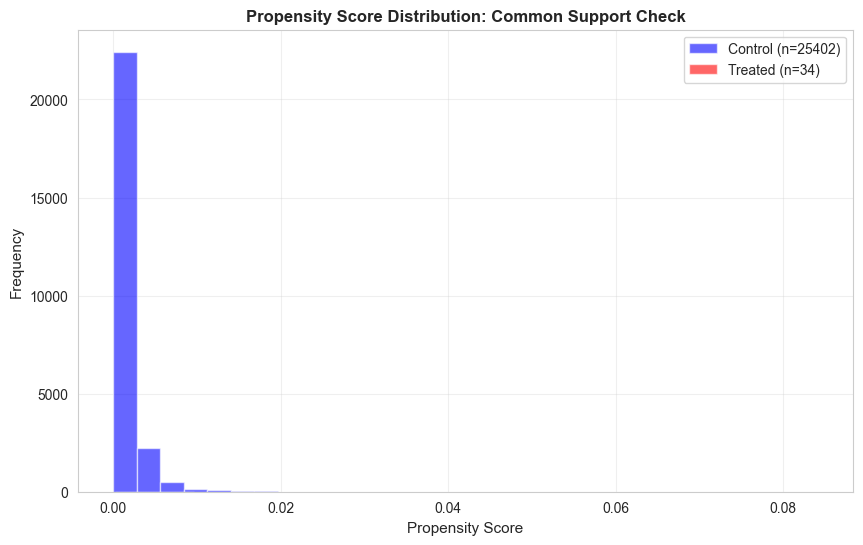

In [3]:
# ============================================================
# PROPENSITY SCORE MATCHING (Enhanced)
# ============================================================

from asean_green_bonds import analysis, config
from asean_green_bonds.analysis import (
    estimate_propensity_scores,
    calculate_optimal_caliper,
    trim_extreme_propensity_scores,
    nearest_neighbor_matching,
    check_common_support,
    assess_balance
)

print('\n' + '='*60)
print('PROPENSITY SCORE MATCHING')
print('='*60)

# Estimate propensity scores
ps_features = config.PSM_FEATURES
print(f'\nPSM Features: {ps_features}')

df['propensity_score'] = estimate_propensity_scores(
    df,
    treatment_col='green_bond_issue',
    features=ps_features
)

print(f'Propensity scores estimated: {df["propensity_score"].notna().sum()} observations')

# Calculate optimal caliper (Austin 2011 method)
ps_valid = df['propensity_score'].dropna()
optimal_caliper = calculate_optimal_caliper(ps_valid, method='austin')
print(f'\nOptimal caliper (0.25 × SD): {optimal_caliper:.4f}')
print(f'  Propensity score SD: {ps_valid.std():.4f}')
print(f'  Fixed caliper comparison: {config.PSM_CALIPER}')

# Trim extreme propensity scores (Crump et al. 2009)
print('\nTrimming extreme propensity scores...')
df_trimmed = trim_extreme_propensity_scores(
    df,
    ps_col='propensity_score',
    treatment_col='green_bond_issue',
    method='percentile',  # Changed from 'crump' - PS values too low for Crump trimming
    alpha=0.1
)
trimmed_count = len(df) - len(df_trimmed)
print(f'  Observations trimmed: {trimmed_count} ({100*trimmed_count/len(df):.1f}%)')

# Safeguard: if trimming removed too many, skip trimming
if len(df_trimmed) < 100:
    print('  ⚠ Trimming removed too many observations, using untrimmed data')
    df_trimmed = df[df['propensity_score'].notna()].copy()

# Check common support
support_report = check_common_support(
    df_trimmed,
    ps_col='propensity_score',
    treatment_col='green_bond_issue'
)

print(f'\nCommon Support Analysis:')
print(f'  Treated mean PS: {support_report["treated_mean_ps"]:.4f} (SD: {support_report["treated_sd_ps"]:.4f})')
print(f'  Control mean PS: {support_report["control_mean_ps"]:.4f} (SD: {support_report["control_sd_ps"]:.4f})')
print(f'  Overlap region: [{support_report["overlap_region"][0]:.4f}, {support_report["overlap_region"][1]:.4f}]')
print(f'  Violations: {support_report["treated_violations"]} treated, {support_report["control_violations"]} control')

# Perform matching with AUTO caliper
print(f'\nPerforming nearest-neighbor matching (caliper=auto)...')
matched_df, match_stats = nearest_neighbor_matching(
    df_trimmed,
    ps_col='propensity_score',
    treatment_col='green_bond_issue',
    caliper='auto',  # Uses calculated optimal caliper
    ratio=config.PSM_RATIO,
    replacement=False
)

print(f'\nMatching Results:')
print(f'  Treated units: {match_stats["treated_units"]}')
print(f'  Matched treated: {match_stats["matched_treated"]}')
print(f'  Unmatched treated: {match_stats["unmatched_treated"]}')
print(f'  Matched controls: {match_stats["matched_controls"]}')
print(f'  Total matched observations: {match_stats["total_matched_obs"]}')
print(f'  Caliper used: {match_stats.get("caliper", optimal_caliper):.4f}')

# Assess balance
print('\nCovariate Balance After Matching:')
balance_df = assess_balance(matched_df, ps_features, treatment_col='green_bond_issue')
if len(balance_df) > 0:
    print(balance_df[['Feature', 'Std_Difference', 'P_Value', 'Balanced']].to_string(index=False))
    balanced_count = balance_df['Balanced'].sum()
    print(f'\n✓ {balanced_count}/{len(balance_df)} covariates balanced (|std diff| < 0.1)')
else:
    print('  No features to assess (check if features exist in matched data)')

# Visualize
fig = utils.plot_propensity_score_overlap(
    df,
    save_path='images/01_propensity_scores.png'
)
print('\n✅ Saved: 01_propensity_scores.png')

In [4]:
# Run DiD for multiple outcomes
print('\n' + '='*60)
print('DIFFERENCE-IN-DIFFERENCES ESTIMATION')
print('='*60)

outcomes = ['return_on_assets', 'Tobin_Q', 'esg_score']
specs = ['entity_fe', 'time_fe', 'twoway_fe', 'none']

results = analysis.run_multiple_outcomes(
    df,
    outcomes=outcomes,
    treatment_col='green_bond_active',
    specifications=specs
)

print(f'\nEstimated {len(results)} models')
print('\nResults Summary:')
print(results[['outcome', 'specification', 'coefficient', 'std_error', 'p_value']].head(12))


DIFFERENCE-IN-DIFFERENCES ESTIMATION

Estimated 12 models

Results Summary:
             outcome specification  coefficient  std_error       p_value
0   return_on_assets     entity_fe    -0.009946   0.004689  3.391669e-02
1   return_on_assets       time_fe     0.012211   0.007182  8.912390e-02
2   return_on_assets     twoway_fe    -0.007101   0.005267  1.776128e-01
3   return_on_assets          none     0.013651   0.007004  5.130523e-02
4            Tobin_Q     entity_fe    -0.033495   0.064960  6.061164e-01
5            Tobin_Q       time_fe    -0.013441   0.136072  9.213162e-01
6            Tobin_Q     twoway_fe    -0.017395   0.068719  8.001657e-01
7            Tobin_Q          none    -0.127090   0.140621  3.661228e-01
8          esg_score     entity_fe     6.259483   1.755911  3.682409e-04
9          esg_score       time_fe    12.988620   2.407088  7.124323e-08
10         esg_score     twoway_fe     0.752574   2.362786  7.501134e-01
11         esg_score          none    11.371261


Parallel Trends Testing (Leads/Lags)...

Leads and Lags of Treatment:
  treatment_lead_1              :   0.0018     (p=0.6213)
  treatment_lead_2              :   0.0023     (p=0.5961)
  treatment_lead_3              :  -0.0055 *   (p=0.0747)
  green_bond_active             :  -0.0241 *** (p=0.0024)
  treatment_lag_1               :   0.0058     (p=0.4130)
  treatment_lag_2               :   0.0164     (p=0.2211)
  treatment_lag_3               :  -0.0187 *   (p=0.0525)

✅ Saved: 02_parallel_trends.png


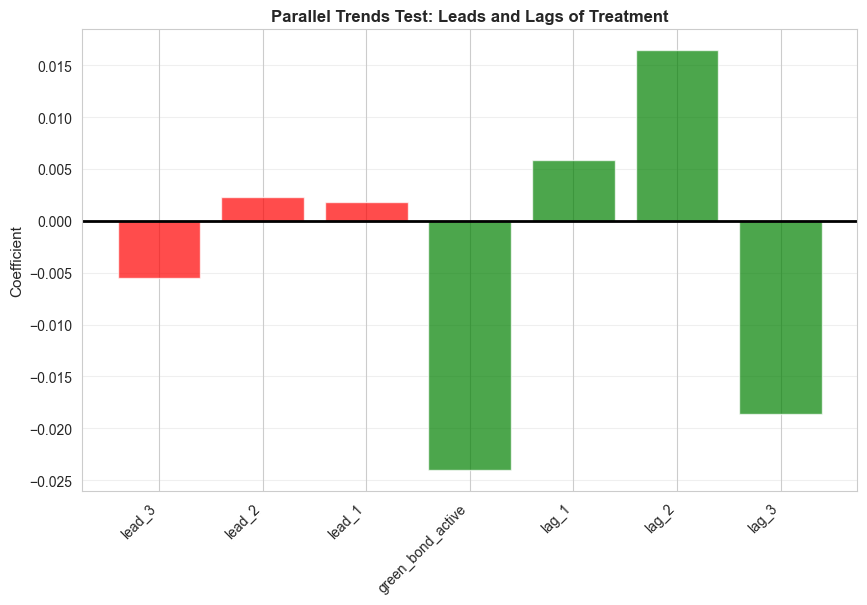

In [5]:
# Test parallel trends assumption
print('\nParallel Trends Testing (Leads/Lags)...')

pt_results = analysis.parallel_trends_test(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active',
    leads=3,
    lags=3
)

print('\nLeads and Lags of Treatment:')
for col, coef in pt_results['coefficients'].items():
    pval = pt_results['p_values'][col]
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    print(f'  {col:30s}: {coef:8.4f} {sig:3s} (p={pval:.4f})')

# Visualize
fig = utils.plot_parallel_trends(pt_results, save_path='images/02_parallel_trends.png')
print('\n✅ Saved: 02_parallel_trends.png')

## System GMM Robustness Check

System GMM (Generalized Method of Moments) provides robustness checks for dynamic panel models. This addresses potential Nickell bias when lagged dependent variables are included.

Key diagnostics:
- **AR(1) test**: Should be significant (expected serial correlation in first differences)
- **AR(2) test**: Should NOT be significant (validates no second-order serial correlation)
- **Sargan/Hansen J-test**: Should NOT be significant (validates instrument exogeneity)

In [6]:
# ============================================================
# SYSTEM GMM ROBUSTNESS CHECK
# ============================================================

from asean_green_bonds.analysis import (
    estimate_system_gmm,
    arellano_bond_test,
    sargan_hansen_test,
    run_gmm_robustness
)
from asean_green_bonds.config import GMM_CONFIG

print('\n' + '='*60)
print('SYSTEM GMM ROBUSTNESS CHECK')
print('='*60)

# Use full panel data for GMM (matching shrinks panel and can break lag instruments)
gmm_data = df.copy()

outcomes = config.OUTCOME_VARIABLES
print(f'\nOutcomes to analyze: {outcomes}')
print(f'GMM Configuration: max_lags={GMM_CONFIG["max_lags"]}, robust_se={GMM_CONFIG["robust_se"]}')

gmm_results = []

for outcome in outcomes:
    print(f'\n--- {outcome} ---')
    
    # Adaptive instrument coverage for sparse outcomes (e.g., ESG)
    gmm_thresholds = [0.30, 0.10, 0.08]
    result = None
    used_threshold = None

    for threshold in gmm_thresholds:
        trial = estimate_system_gmm(
            gmm_data,
            outcome=outcome,
            treatment_col='green_bond_active',
            entity_col='ric',
            time_col='Year',
            control_vars=config.CONTROL_VARIABLES,
            max_lags=GMM_CONFIG['max_lags'],
            min_obs_fraction=threshold
        )

        if 'error' not in trial:
            result = trial
            used_threshold = threshold
            break

        if trial.get('error') != 'No valid instruments available':
            result = trial
            used_threshold = threshold
            break

    if result is not None and 'error' not in result:
        print(f'  Instrument min_obs_fraction used: {used_threshold:.2f}')
        print(f'  Treatment coefficient: {result["coefficient"]:.4f}')
        print(f'  Std error: {result["std_error"]:.4f}')
        print(f'  t-statistic: {result["t_statistic"]:.2f}')
        print(f'  p-value: {result["p_value"]:.4f}')
        print(f'  Observations: {result["n_obs"]}')
        
        # Diagnostic tests
        if 'ar1_pvalue' in result:
            ar1_sig = '✓' if result['ar1_pvalue'] < 0.10 else '✗'
            print(f'  AR(1) test p-value: {result["ar1_pvalue"]:.4f} {ar1_sig} (should be significant)')
        if 'ar2_pvalue' in result:
            ar2_sig = '✓' if result['ar2_pvalue'] > 0.10 else '✗'
            print(f'  AR(2) test p-value: {result["ar2_pvalue"]:.4f} {ar2_sig} (should NOT be significant)')
        if 'sargan_pvalue' in result:
            sargan_sig = '✓' if result['sargan_pvalue'] > 0.10 else '✗'
            print(f'  Sargan test p-value: {result["sargan_pvalue"]:.4f} {sargan_sig} (should NOT be significant)')
        
        gmm_results.append(result)
    else:
        err_msg = result['error'] if isinstance(result, dict) and 'error' in result else 'Unknown GMM failure'
        print(f'  Error: {err_msg}')

# Summary table
if gmm_results:
    print('\n' + '='*60)
    print('GMM RESULTS SUMMARY')
    print('='*60)
    
    import pandas as pd
    summary_df = pd.DataFrame([{
        'Outcome': r['outcome'],
        'Coefficient': f"{r['coefficient']:.4f}",
        'Std Error': f"{r['std_error']:.4f}",
        't-stat': f"{r['t_statistic']:.2f}",
        'p-value': f"{r['p_value']:.4f}",
        'Sig': '***' if r['p_value'] < 0.01 else '**' if r['p_value'] < 0.05 else '*' if r['p_value'] < 0.10 else ''
    } for r in gmm_results])
    
    print(summary_df.to_string(index=False))
    print('\nNote: *** p<0.01, ** p<0.05, * p<0.10')


SYSTEM GMM ROBUSTNESS CHECK

Outcomes to analyze: ['return_on_assets', 'Tobin_Q', 'esg_score']
GMM Configuration: max_lags=3, robust_se=True

--- return_on_assets ---
  Instrument min_obs_fraction used: 0.30
  Treatment coefficient: -0.0048
  Std error: 0.0026
  t-statistic: -1.81
  p-value: 0.0706
  Observations: 18133
  AR(1) test p-value: 0.5602 ✗ (should be significant)
  AR(2) test p-value: 0.9692 ✓ (should NOT be significant)
  Sargan test p-value: nan ✗ (should NOT be significant)

--- Tobin_Q ---
  Instrument min_obs_fraction used: 0.30
  Treatment coefficient: -0.0169
  Std error: 0.0362
  t-statistic: -0.47
  p-value: 0.6411
  Observations: 16455
  AR(1) test p-value: 0.6178 ✗ (should be significant)
  AR(2) test p-value: 0.9877 ✓ (should NOT be significant)
  Sargan test p-value: nan ✗ (should NOT be significant)

--- esg_score ---
  Instrument min_obs_fraction used: 0.08
  Treatment coefficient: 0.1777
  Std error: 0.5725
  t-statistic: 0.31
  p-value: 0.7563
  Observation

In [7]:
# Compare DiD and GMM results
print('\n' + '='*60)
print('DiD vs GMM COMPARISON')
print('='*60)

if 'results' in dir() and gmm_results:
    did_results = results[results['specification'] == 'twoway_fe']

    print('\n{:<20} {:>12} {:>12} {:>12}'.format('Outcome', 'DiD Coef', 'GMM Coef', 'Difference'))
    print('-' * 60)

    printed = 0
    for outcome in outcomes:
        did_row = did_results[did_results['outcome'] == outcome]
        gmm_row = [r for r in gmm_results if r.get('outcome') == outcome]

        if len(did_row) > 0 and len(gmm_row) > 0:
            did_coef = did_row['coefficient'].values[0]
            gmm_coef = gmm_row[0]['coefficient']
            diff = gmm_coef - did_coef
            print('{:<20} {:>12.4f} {:>12.4f} {:>12.4f}'.format(outcome, did_coef, gmm_coef, diff))
            printed += 1
        else:
            missing = []
            if len(did_row) == 0:
                missing.append('DiD')
            if len(gmm_row) == 0:
                missing.append('GMM')
            print('{:<20} {:>12} {:>12} {:>12}'.format(outcome, 'NA', 'NA', f"missing {'/'.join(missing)}"))

    if printed == 0:
        print('\nNo overlapping DiD/GMM outcomes available for comparison.')
    else:
        print('\nNote: Similar coefficients across methods suggest robust treatment effects.')
else:
    print('Run DiD and GMM sections first to enable comparison.')



DiD vs GMM COMPARISON

Outcome                  DiD Coef     GMM Coef   Difference
------------------------------------------------------------
return_on_assets          -0.0071      -0.0048       0.0023
Tobin_Q                   -0.0174      -0.0169       0.0005
esg_score                  0.7526       0.1777      -0.5749

Note: Similar coefficients across methods suggest robust treatment effects.


In [8]:
# Run specification sensitivity
print('\n' + '='*60)
print('ROBUSTNESS CHECKS')
print('='*60)

sensitivity = analysis.specification_sensitivity(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active'
)

print('\nSpecification Sensitivity:')
print(sensitivity[['specification', 'n_controls', 'coefficient', 'std_error', 'p_value']].to_string())

# Placebo test
placebo = analysis.placebo_test(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active'
)

print(f'\nPlacebo Test (shifted treatment):')  
print(f'  Placebo effect: {placebo.get("placebo_coefficient", np.nan):.4f}')
print(f'  p-value: {placebo.get("placebo_p_value", np.nan):.4f}')
print(f'  ✓ Valid' if placebo.get('is_zero_at_5pct') else '  ✗ Concern')


ROBUSTNESS CHECKS

Specification Sensitivity:
  specification  n_controls  coefficient  std_error   p_value
0        Spec_1           0    -0.019847   0.004464  0.000009
1        Spec_2           1    -0.009629   0.004751  0.042692
2        Spec_3           2    -0.009591   0.004737  0.042913
3        Spec_4           3    -0.011196   0.004656  0.016205
4        Spec_5           4    -0.009946   0.004689  0.033917

Placebo Test (shifted treatment):
  Placebo effect: -0.0166
  p-value: 0.0015
  ✗ Concern


In [9]:
# Run full diagnostics
print('\nRunning comprehensive diagnostic tests...')

diagnostics = analysis.run_diagnostics_battery(
    df,
    outcome='return_on_assets'
)

print('\n✅ Diagnostics Complete')
print(f'  Placebo: {diagnostics["placebo"].get("is_zero_at_5pct", "N/A")}')
print(f'  LOOCV robustness: {diagnostics["loocv"].get("robust", "N/A")}')
print(f'  Specifications tested: {len(diagnostics["spec_sensitivity"])}')


Running comprehensive diagnostic tests...
Running placebo test...
Running specification sensitivity...
Running leave-one-out CV...
Analyzing heterogeneous effects...

✅ Diagnostics Complete
  Placebo: False
  LOOCV robustness: True
  Specifications tested: 5


In [10]:
print('\n' + '='*60)
print('ANALYSIS COMPLETE')
print('='*60)
print('\n✅ Outputs saved to images/')
print('\nKey results:')
print(f'  - {len(results)} DiD estimates (outcomes × specifications)')
print(f'  - Parallel trends tested (leads/lags)') 
print(f'  - Robustness checks completed')
print(f'  - Visualizations created')
print('\nNext: Review results and visualizations in images/')


ANALYSIS COMPLETE

✅ Outputs saved to images/

Key results:
  - 12 DiD estimates (outcomes × specifications)
  - Parallel trends tested (leads/lags)
  - Robustness checks completed
  - Visualizations created

Next: Review results and visualizations in images/
